## Instalasi Library

In [8]:
!pip install opencv-python
!pip install matplotlib
!pip install numpy

## Import Library

In [2]:
#202431166_Muhammad Farhan Fahrezy
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Membaca Citra

In [3]:
#202431166_Muhammad Farhan Fahrezy
citra = cv2.imread('citra2.jpeg')

## Menampilkan Citra Awal

In [4]:
cv2.imshow('Citra Awal', citra)
cv2.waitKey()
cv2.destroyAllWindows()

## Convert BGR to RGB

In [5]:
#202431166_Muhammad Farhan Fahrezy
rgb = cv2.cvtColor(citra, cv2.COLOR_BGR2RGB)

## Split Citra

In [6]:
# Pisah kanal B, G, R[web:7]
b, g, r = cv2.split(citra)

## Ekstrak Channel Warna

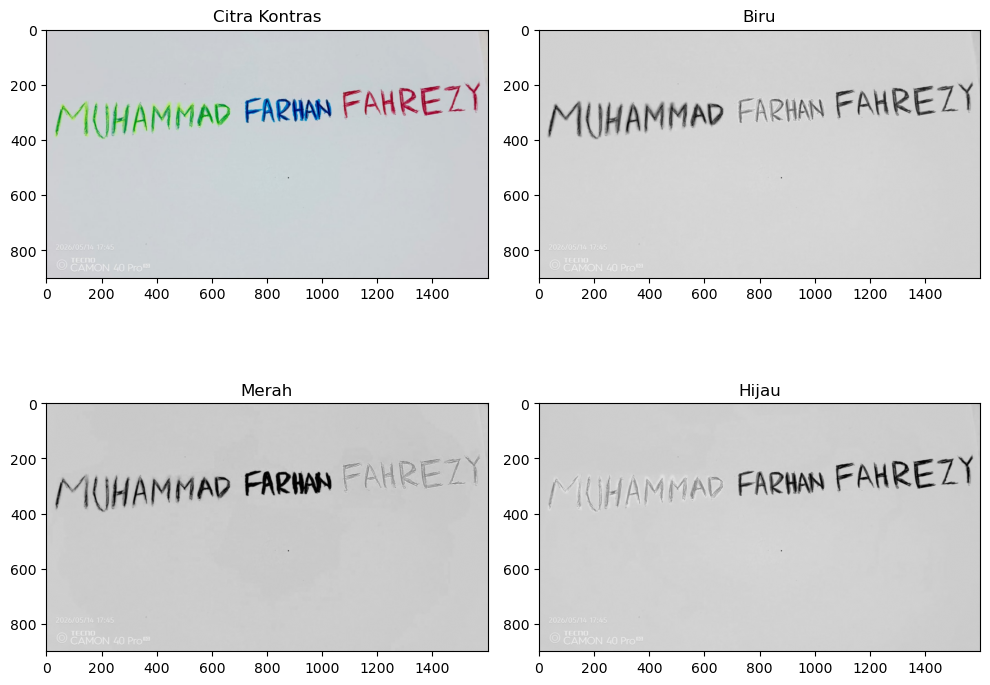

In [7]:
#202431166_Muhammad Farhan Fahrezy
plt.figure(figsize=(10, 8))

# Citra Kontras
plt.subplot(2, 2, 1)
plt.imshow(rgb)
plt.title("Citra Kontras")
plt.axis("on")

# Kanal Biru
plt.subplot(2, 2, 2)
plt.imshow(b, cmap='gray')
plt.title("Biru")
plt.axis("on")

# Kanal Merah
plt.subplot(2, 2, 3)
plt.imshow(r, cmap='gray')
plt.title("Merah")
plt.axis("on")

# Kanal Hijau
plt.subplot(2, 2, 4)
plt.imshow(g, cmap='gray')
plt.title("Hijau")
plt.axis("on")

plt.tight_layout()
plt.show()

## Membuat Histogram

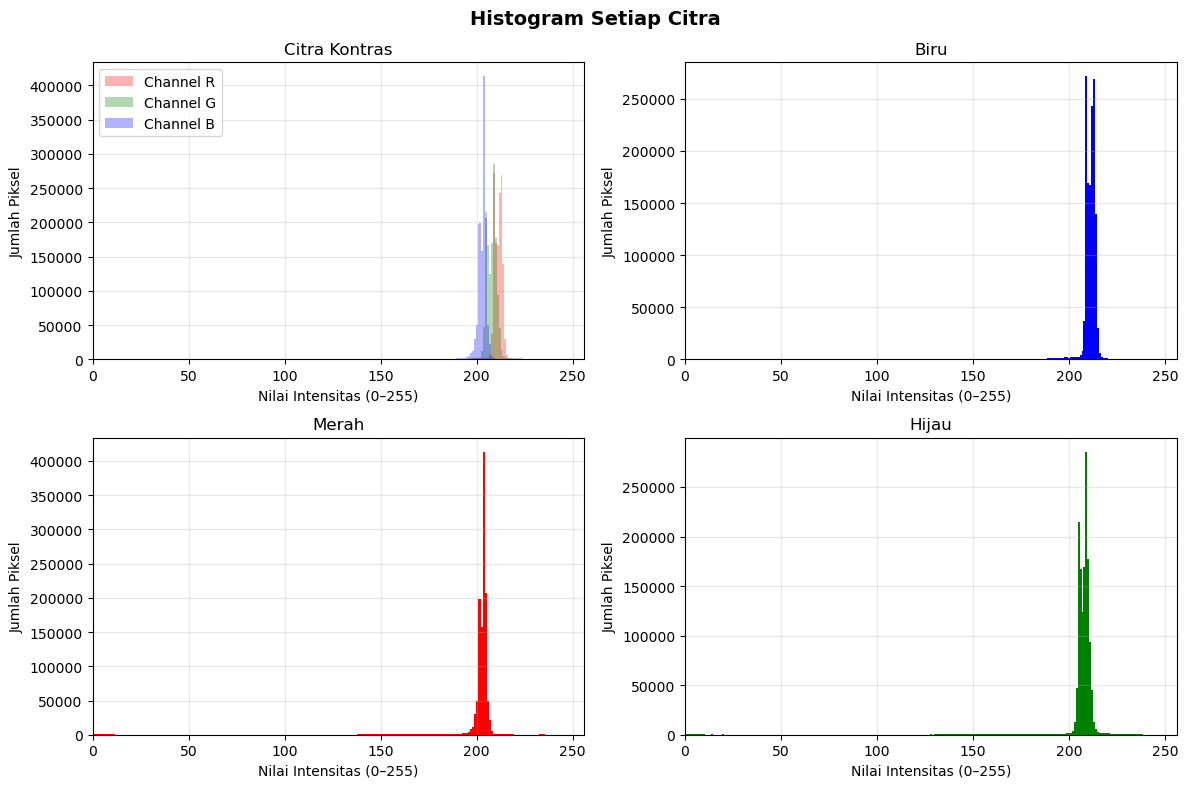

In [8]:
#202431166_Muhammad Farhan Fahrezy
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Histogram Setiap Citra", fontsize=14, fontweight='bold')

# Histogram RGB
ax = axes[0, 0]
colors = ('red', 'green', 'blue')
labels = ('Channel R', 'Channel G', 'Channel B')
bins = np.arange(256)  # posisi batang 0–255

for i, (col, label) in enumerate(zip(colors, labels)):
    hist = cv2.calcHist([citra], [i], None, [256], [0, 256]).flatten()
    ax.bar(bins, hist, color=col, label=label, alpha=0.3, width=1.0)

ax.set_title("Citra Kontras")
ax.set_xlabel("Nilai Intensitas (0–255)")
ax.set_ylabel("Jumlah Piksel")
ax.legend()
ax.set_xlim([0, 256])
ax.grid(True, alpha=0.3)

# Histogram Kanal Biru
ax = axes[0, 1]
hist_b = cv2.calcHist([b], [0], None, [256], [0, 256]).flatten()
ax.bar(bins, hist_b, color='blue', width=1.0)
ax.set_title("Biru")
ax.set_xlabel("Nilai Intensitas (0–255)")
ax.set_ylabel("Jumlah Piksel")
ax.set_xlim([0, 256])
ax.grid(True, alpha=0.3)

#202431166_Muhammad Farhan Fahrezy
# Histogram Kanal Merah
ax = axes[1, 0]
hist_r = cv2.calcHist([r], [0], None, [256], [0, 256]).flatten()
ax.bar(bins, hist_r, color='red', width=1.0)
ax.set_title("Merah")
ax.set_xlabel("Nilai Intensitas (0–255)")
ax.set_ylabel("Jumlah Piksel")
ax.set_xlim([0, 256])
ax.grid(True, alpha=0.3)

# Histogram Kanal Hijau
ax = axes[1, 1]
hist_g = cv2.calcHist([g], [0], None, [256], [0, 256]).flatten()
ax.bar(bins, hist_g, color='green', width=1.0)
ax.set_title("Hijau")
ax.set_xlabel("Nilai Intensitas (0–255)")
ax.set_ylabel("Jumlah Piksel")
ax.set_xlim([0, 256])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
for kanal, nama in zip([r, g, b], ['Merah (R)', 'Hijau (G)', 'Biru (B)']):
    print(f"\nKanal {nama}:")
    print(f"  Min Intensitas : {kanal.min()}")
    print(f"  Max Intensitas : {kanal.max()}")
    print(f"  Rata-rata      : {kanal.mean():.2f}")
    print(f"  Std Deviasi    : {kanal.std():.2f}")


Kanal Merah (R):
  Min Intensitas : 0
  Max Intensitas : 255
  Rata-rata      : 198.93
  Std Deviasi    : 24.57

Kanal Hijau (G):
  Min Intensitas : 0
  Max Intensitas : 255
  Rata-rata      : 204.62
  Std Deviasi    : 21.78

Kanal Biru (B):
  Min Intensitas : 0
  Max Intensitas : 255
  Rata-rata      : 207.14
  Std Deviasi    : 22.68


## Mencari Ambang Batas Threshold

T_gray (tulisan vs kertas): 149.0
Ambang Batas MERAH (T_R): 0
Ambang Batas HIJAU (T_G): 0
Ambang Batas BIRU  (T_B): 0


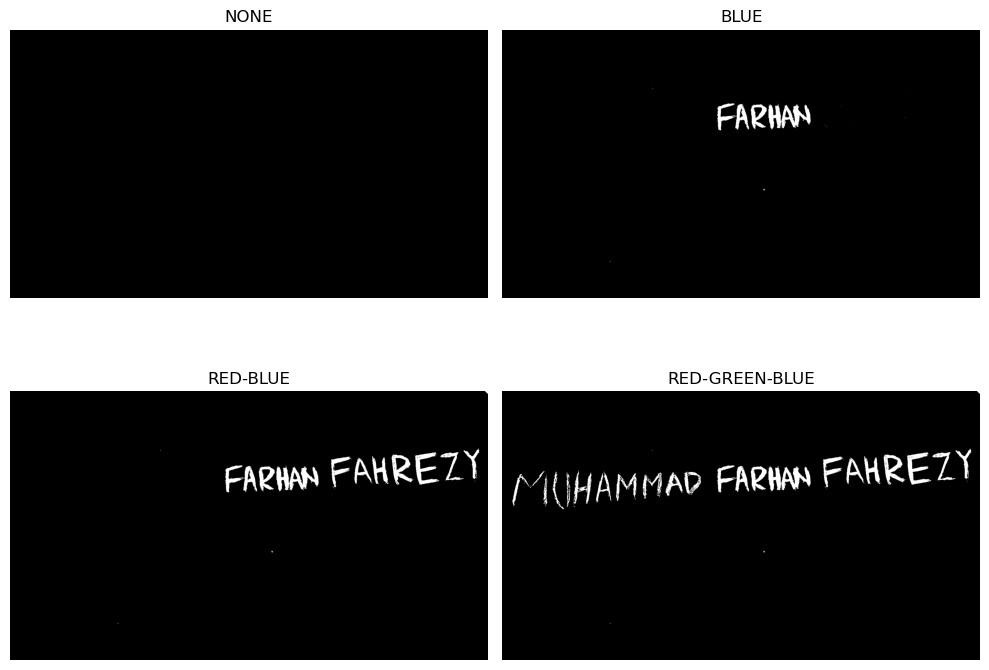

In [12]:
# RGB to Grayscale dengan OpenCV
citra_gray = cv2.cvtColor(rgb, cv2.COLOR_BGR2GRAY)

# Grayscale to Biner (Otsu - Pisahkan Tulisan vs Latar Belakang)
T_gray, th_gray = cv2.threshold(
    citra_gray, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

mask_tulisan = th_gray == 255
print("T_gray (tulisan vs kertas):", T_gray)

# Menghitung Dominansi Kanal Warna (R, G, B) di Area Tulisan
R = r.astype(np.int16)
G = g.astype(np.int16)
B = b.astype(np.int16)

diff_R = R - np.maximum(G, B)
diff_G = G - np.maximum(R, B)
diff_B = B - np.maximum(R, G)

diff_R_masked = diff_R[mask_tulisan]
diff_G_masked = diff_G[mask_tulisan]
diff_B_masked = diff_B[mask_tulisan]

# Menentukan Ambang Batas Tiap Kanal (Otsu pada Area Tulisan)
shift = 255

diff_R_shift = np.clip(diff_R_masked + shift, 0, 255).astype(np.uint8)
diff_G_shift = np.clip(diff_G_masked + shift, 0, 255).astype(np.uint8)
diff_B_shift = np.clip(diff_B_masked + shift, 0, 255).astype(np.uint8)

T_R, _ = cv2.threshold(diff_R_shift.reshape(-1, 1), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
T_G, _ = cv2.threshold(diff_G_shift.reshape(-1, 1), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
T_B, _ = cv2.threshold(diff_B_shift.reshape(-1, 1), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

T_R_real = max(int(T_R) - shift, 0)
T_G_real = max(int(T_G) - shift, 0)
T_B_real = max(int(T_B) - shift, 0)

print("Ambang Batas MERAH (T_R):", T_R_real)
print("Ambang Batas HIJAU (T_G):", T_G_real)
print("Ambang Batas BIRU  (T_B):", T_B_real)

# Membuat Mask Kategori Warna (Hanya Huruf yang Dominan)
mask_merah = mask_tulisan & (diff_R > T_R_real) & (diff_R > 0)
mask_hijau = mask_tulisan & (diff_G > T_G_real) & (diff_G > 0)
mask_biru  = mask_tulisan & (diff_B > T_B_real) & (diff_B > 0)

bin_merah = np.zeros_like(citra_gray)
bin_hijau = np.zeros_like(citra_gray)
bin_biru  = np.zeros_like(citra_gray)

bin_merah[mask_merah] = 255
bin_hijau[mask_hijau] = 255
bin_biru[mask_biru]   = 255

# Menampilkan Hasil Segmentasi Warna
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(np.zeros_like(citra_gray), cmap='gray')
plt.title("NONE")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(bin_biru, cmap='gray')
plt.title("BLUE")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(cv2.bitwise_or(bin_merah, bin_biru), cmap='gray')
plt.title("RED-BLUE")
plt.axis("off")

plt.subplot(2, 2, 4)
rgb_all = cv2.bitwise_or(bin_merah, cv2.bitwise_or(bin_hijau, bin_biru))
plt.imshow(rgb_all, cmap='gray')
plt.title("RED-GREEN-BLUE")
plt.axis("off")

plt.tight_layout()
plt.show()

# OPERASI PIKSEL

## Membaca Gambar

In [96]:
# 202431166_Muhammad Farhan Fahrezy
img = cv2.imread('citra_backlight.jpeg')

In [97]:
cv2.imshow('Gambar Backlight', img)
cv2.waitKey()
cv2.destroyAllWindows()

## Convert BGR to RGB

In [98]:
# 202431166_Muhammad Farhan Fahrezy
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

## Convert BGR to Gray with OPENCV

In [99]:
citra_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [100]:
cv2.imshow('Citra Abu', citra_gray)
cv2.waitKey()
cv2.destroyAllWindows()

## Operasi Piksel Menambahkan Kecerahan

In [101]:
# 202431166_Muhammad Farhan Fahrezy
[baris, kolom] = img.shape[:2]

## Operasi Piksel Menambah Kecerahan

C:\Users\Rafael\AppData\Local\Temp\ipykernel_3776\3321931385.py:17: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axs[0, 1].hist(rgb.ravel(), 256, [0, 256])
C:\Users\Rafael\AppData\Local\Temp\ipykernel_3776\3321931385.py:25: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axs[1, 1].hist(citra_cerah.ravel(), 256, [0, 256])


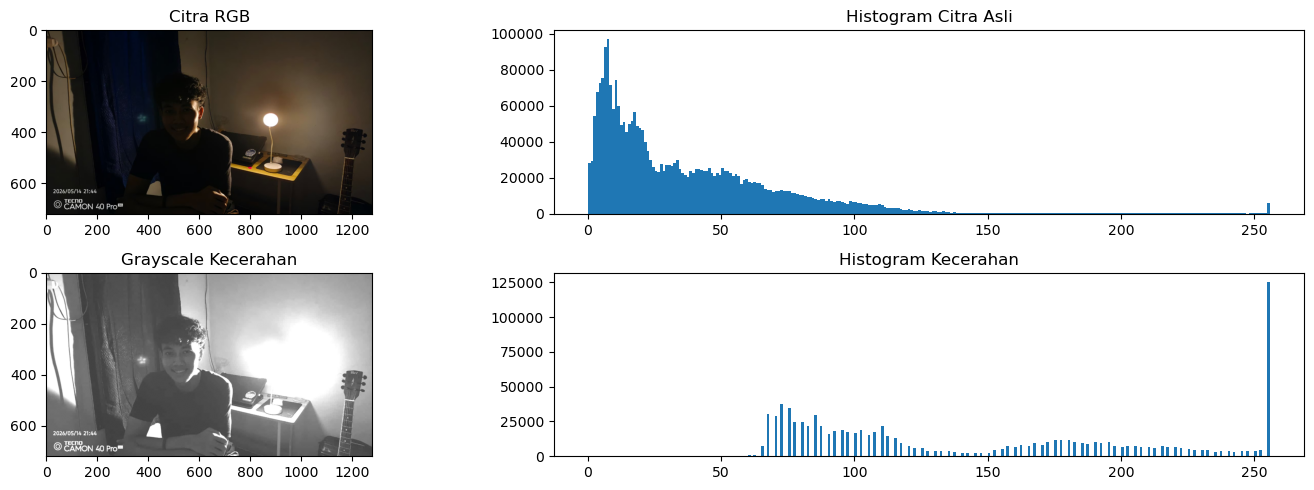

In [108]:
# 202431166_Muhammad Farhan Fahrezy
beta = 80
citra_cerah = np.zeros((baris, kolom), dtype=np.int16)  
for x in range(baris):
    for y in range(kolom):
        gyx = beta + int(citra_gray[x, y]) 
        citra_cerah[x, y] = gyx

citra_cerah = np.clip(citra_kombinasi, 0, 255).astype(np.uint8)
fig, axs = plt.subplots(2, 2, figsize=(15, 5))

# gambar asli (RGB)
axs[0, 0].imshow(rgb)                 
axs[0, 0].set_title('Citra RGB')

# histogram grayscale asli
axs[0, 1].hist(rgb.ravel(), 256, [0, 256])
axs[0, 1].set_title('Histogram Citra Asli')

# citra grayscale yang sudah ditambah kecerahan
axs[1, 0].imshow(citra_cerah, cmap='gray', vmin=0, vmax=255)
axs[1, 0].set_title('Grayscale Kecerahan')

# histogram setelah kecerahan ditambah
axs[1, 1].hist(citra_cerah.ravel(), 256, [0, 256])
axs[1, 1].set_title('Histogram Kecerahan')

plt.tight_layout()
plt.show()

## Operasi Piksel Meregangkan Kontras

C:\Users\Rafael\AppData\Local\Temp\ipykernel_3776\541189669.py:19: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axs[0, 1].hist(rgb.ravel(), 256, [0, 256])
C:\Users\Rafael\AppData\Local\Temp\ipykernel_3776\541189669.py:27: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axs[1, 1].hist(citra_kontras.ravel(), 256, [0, 256])


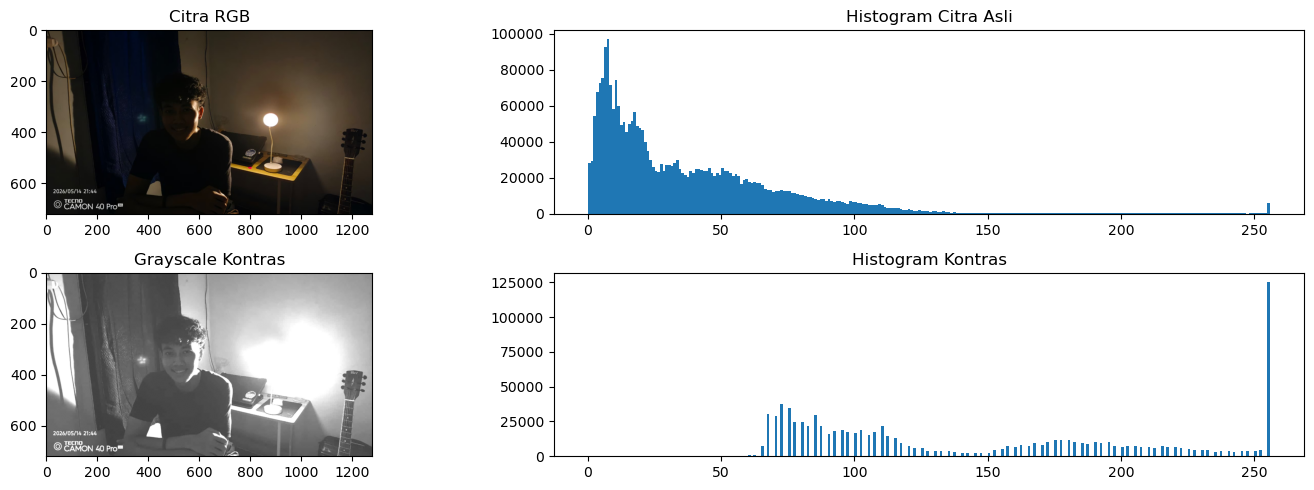

In [107]:
# 202431166_Muhammad Farhan Fahrezy
alpha = 2.7
citra_kontras = np.zeros((baris, kolom), dtype=np.int16)  

for x in range(baris):
    for y in range(kolom):
        gyx = int(citra_gray[x, y]) * alpha 
        citra_kontras[x, y] = gyx


citra_kontras = np.clip(citra_kombinasi, 0, 255).astype(np.uint8)
fig, axs = plt.subplots(2, 2, figsize=(15, 5))

# gambar asli (RGB)
axs[0, 0].imshow(rgb)                 
axs[0, 0].set_title('Citra RGB')

# histogram grayscale asli
axs[0, 1].hist(rgb.ravel(), 256, [0, 256])
axs[0, 1].set_title('Histogram Citra Asli')

# citra grayscale yang sudah ditambah kecerahan
axs[1, 0].imshow(citra_kontras, cmap='gray', vmin=0, vmax=255)
axs[1, 0].set_title('Grayscale Kontras')

# histogram setelah kecerahan ditambah
axs[1, 1].hist(citra_kontras.ravel(), 256, [0, 256])
axs[1, 1].set_title('Histogram Kontras')

plt.tight_layout()
plt.show()

C:\Users\Rafael\AppData\Local\Temp\ipykernel_3776\2017452059.py:20: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axs[0, 1].hist(rgb.ravel(), 256, [0, 256])
C:\Users\Rafael\AppData\Local\Temp\ipykernel_3776\2017452059.py:28: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axs[1, 1].hist(citra_kombinasi.ravel(), 256, [0, 256])


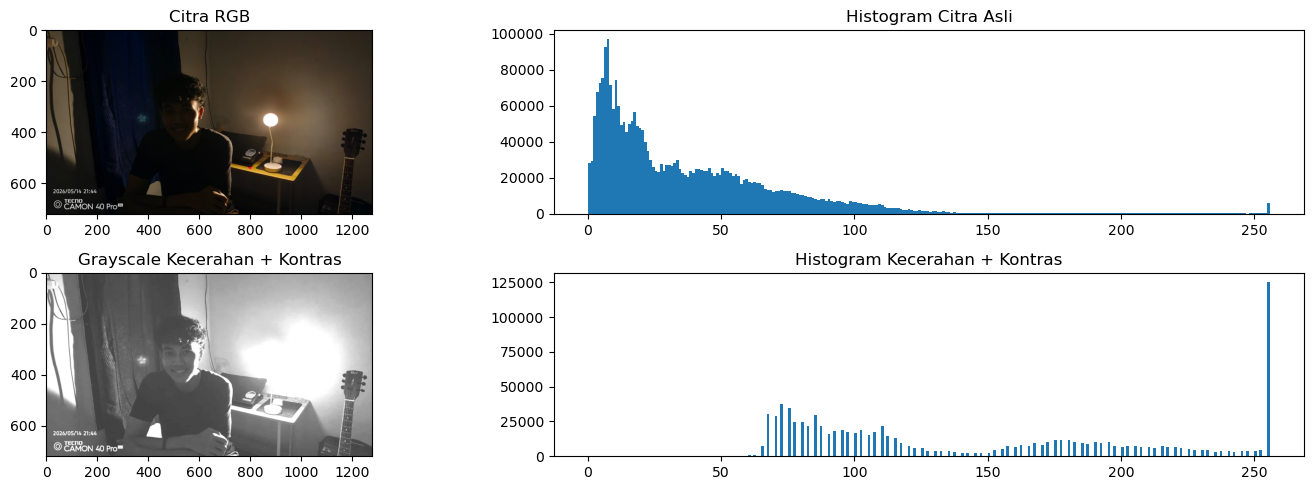

In [111]:
# 202431166_Muhammad Farhan Fahrezy
alpha = 2.5
beta = 60
citra_kombinasi = np.zeros((baris, kolom), dtype=np.int16)  

for x in range(baris):
    for y in range(kolom):
        gyx = beta + int(citra_gray[x, y]) * alpha 
        citra_kombinasi[x, y] = gyx


citra_kombinasi = np.clip(citra_kombinasi, 0, 255).astype(np.uint8)
fig, axs = plt.subplots(2, 2, figsize=(15, 5))

# gambar asli (RGB)
axs[0, 0].imshow(rgb)               
axs[0, 0].set_title('Citra RGB')

# histogram grayscale asli
axs[0, 1].hist(rgb.ravel(), 256, [0, 256])
axs[0, 1].set_title('Histogram Citra Asli')

# citra grayscale yang sudah ditambah kecerahan
axs[1, 0].imshow(citra_kombinasi, cmap='gray', vmin=0, vmax=255)
axs[1, 0].set_title('Grayscale Kecerahan + Kontras')

# histogram setelah kecerahan ditambah
axs[1, 1].hist(citra_kombinasi.ravel(), 256, [0, 256])
axs[1, 1].set_title('Histogram Kecerahan + Kontras')

plt.tight_layout()
plt.show()

In [113]:
cv2.imwrite('citra_kombinasi.png', citra_kombinasi)   

True

In [114]:
cv2.imwrite('citra_gray.png', citra_gray)   

True

In [115]:
cv2.imwrite('citra_kecerahan.png', citra_cerah)

True

In [116]:
cv2.imwrite('citra_kontras.png', citra_kontras)

True